# Load Shedding's Economic Ripple Effect
**Does the severity and duration of load shedding measurably move South African economic activity — and by how much, with what time lag?**


This notebook is the full analysis pipeline: data loading → cleaning → EDA → statistical testing → modelling → findings. Narrative is written between cells, research-report style.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
import statsmodels.api as sm

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
RAW = "../data/raw/"
PROCESSED = "../data/processed/"
CHARTS = "../charts/"

In [2]:
import os
print(os.listdir(RAW))

['Eskom 5Y Data Request.zip', 'P6242.1 Retail trade sales (New time series) from January 2002_202604.zip', 'SOURCES.md']


In [3]:
import zipfile

with zipfile.ZipFile(RAW + "Eskom 5Y Data Request.zip") as z:
    print("--- Eskom zip contents ---")
    for name in z.namelist():
        print(name)

with zipfile.ZipFile(RAW + "P6242.1 Retail trade sales (New time series) from January 2002_202604.zip") as z:
    print("--- StatsSA zip contents ---")
    for name in z.namelist():
        print(name)

--- Eskom zip contents ---
ZendTo-9q6BDt72hgoRHxsk/ESK19149.csv
--- StatsSA zip contents ---
EXCEL/
EXCEL/Retail trade sales from 2002.xlsx


In [4]:
import zipfile
import pandas as pd

# Peek at the Eskom CSV
with zipfile.ZipFile(RAW + "Eskom 5Y Data Request.zip") as z:
    with z.open("ZendTo-9q6BDt72hgoRHxsk/ESK19149.csv") as f:
        eskom_preview = pd.read_csv(f, nrows=5)

print("--- Eskom CSV: columns ---")
print(list(eskom_preview.columns))
display(eskom_preview)

# Peek at the StatsSA Excel file
with zipfile.ZipFile(RAW + "P6242.1 Retail trade sales (New time series) from January 2002_202604.zip") as z:
    with z.open("EXCEL/Retail trade sales from 2002.xlsx") as f:
        xls = pd.ExcelFile(f)
        print("--- StatsSA Excel: sheet names ---")
        print(xls.sheet_names)
        retail_preview = xls.parse(xls.sheet_names[0], nrows=10)

print("--- StatsSA Excel: first 10 rows of first sheet ---")
display(retail_preview)

--- Eskom CSV: columns ---
['Date Time Hour Beginning', 'Original Res Forecast before Lockdown', 'Residual Forecast', 'RSA Contracted Forecast', 'Dispatchable Generation', 'Residual Demand', 'RSA Contracted Demand', 'International Exports', 'International Imports', 'Thermal Generation', 'Nuclear Generation', 'Eskom Gas Generation', 'Eskom OCGT Generation', 'Hydro Water Generation', 'Pumped Water Generation', 'ILS Usage', 'Manual Load_Reduction(MLR)', 'IOS Excl ILS and MLR', 'Dispatchable IPP OCGT', 'Eskom Gas SCO', 'Eskom OCGT SCO', 'Hydro Water SCO', 'Pumped Water SCO Pumping', 'Wind', 'PV', 'CSP', 'Other RE', 'Total RE', 'Wind Installed Capacity', 'PV Installed Capacity', 'CSP Installed Capacity', 'Other RE Installed Capacity', 'Total RE Installed Capacity', 'Installed Eskom Capacity', 'Total PCLF', 'Total UCLF', 'Total OCLF', 'Total UCLF+OCLF', 'Non Comm Sentout', 'Drakensberg Gen Unit Hours', 'Palmiet Gen Unit Hours', 'Ingula Gen Unit Hours']


,Date Time Hour Beginning,Original Res Forecast before Lockdown,Residual Forecast,RSA Contracted Forecast,Dispatchable Generation,Residual Demand,RSA Contracted Demand,International Exports,International Imports,Thermal Generation,...,Total RE Installed Capacity,Installed Eskom Capacity,Total PCLF,Total UCLF,Total OCLF,Total UCLF+OCLF,Non Comm Sentout,Drakensberg Gen Unit Hours,Palmiet Gen Unit Hours,Ingula Gen Unit Hours
0,4/1/2022 12:00:00 AM,22160.133,21324.592,22106.655,21105.801,21105.801,22240.789,1408.507,1068.0,20877.0,...,5926.04,46797.0,6278.0,12114.285,526.750,12641.035,594.0,66.0,27.4,23.28
1,4/1/2022 1:00:00 AM,21737.774,20908.936,21651.713,20936.935,20936.935,22043.880,1404.937,1121.0,20709.0,...,5926.04,46797.0,6650.0,12540.067,500.050,13040.117,590.0,68.2,29.0,25.64
2,4/1/2022 2:00:00 AM,21706.565,20771.960,21466.049,20892.068,20892.068,21880.597,1393.113,1295.0,20498.0,...,5926.04,46797.0,6650.0,12216.002,454.367,12670.369,586.0,70.2,31.0,28.09
3,4/1/2022 3:00:00 AM,21940.481,20896.331,21560.271,20964.935,20964.935,21993.023,1363.370,1337.0,20529.0,...,5926.04,46797.0,6650.0,12014.730,435.093,12449.824,588.0,72.2,32.5,30.56
4,4/1/2022 4:00:00 AM,23045.826,21987.801,22620.957,21886.935,21886.935,22914.172,1460.162,1164.0,21312.0,...,5926.04,46797.0,6650.0,12084.470,436.278,12520.748,595.0,74.2,34.1,33.06


--- StatsSA Excel: sheet names ---
['Retail trade sales from 2002']
--- StatsSA Excel: first 10 rows of first sheet ---


,H01,H02,H03,H04,H05,H15,H16,H17,H25,MO012002,...,MO072025,MO082025,MO092025,MO102025,MO112025,MO122025,MO012026,MO022026,MO032026,MO042026
0,P6242_1,Retail trade sales,con_S621C,Type of dealer,General dealers,At constant prices,Actual values,R million,Monthly,NaN,...,40003,42835,45145,42046,52627,58655,41333,42684,45440,41072
1,P6242_1,Retail trade sales,con_S6220,Type of dealer,"Retailers of food, beverages and tobacco in sp...",At constant prices,Actual values,R million,Monthly,NaN,...,8293,8105,8182,8664,8806,11732,7868,7486,7996,8301
2,P6242_1,Retail trade sales,con_S6231,Type of dealer,"Retailers in pharmaceutical and medical goods,...",At constant prices,Actual values,R million,Monthly,NaN,...,7663,7286,7011,7784,7552,7916,7911,7106,7518,7741
3,P6242_1,Retail trade sales,con_S6232,Type of dealer,"Retailers in textiles,clothing,footwear and le...",At constant prices,Actual values,R million,Monthly,NaN,...,17215,15036,14415,16510,22348,32378,16911,15995,15706,17114
4,P6242_1,Retail trade sales,con_S6233,Type of dealer,"Retailers in household furniture,appliances an...",At constant prices,Actual values,R million,Monthly,NaN,...,4202,4267,4155,4470,5690,6350,4220,4180,4503,4264
5,P6242_1,Retail trade sales,con_S6234,Type of dealer,"Retailers in hardware,paint and glass",At constant prices,Actual values,R million,Monthly,NaN,...,8033,8104,7521,8081,8562,8059,6916,6725,7333,6860
6,P6242_1,Retail trade sales,con_S6239,Type of dealer,All other retailers,At constant prices,Actual values,R million,Monthly,NaN,...,10736,10371,9505,10560,12322,13744,12167,11033,10926,11412
7,P6242_1,Retail trade sales,con_act,Total,NaN,At constant prices,Actual values,R million,Monthly,43977.0,...,96145,96004,95934,98115,117907,138834,97326,95209,99422,96764
8,P6242_1,Retail trade sales,con_seas,Total,NaN,At constant prices,Seasonally adjusted values,R million,Monthly,47303.0,...,102920,101452,101406,102379,103003,102353,103294,102163,102284,103168
9,P6242_1,Retail trade sales,cur_act,Total,NaN,At current prices,Actual values,R million,Monthly,20669.0,...,121450,121981,122318,124151,148405,173595,122834,120692,126626,123076


In [5]:
import zipfile
import pandas as pd

pd.set_option("display.max_colwidth", None)

# --- StatsSA: show every row's category label, without the huge wall of month columns ---
with zipfile.ZipFile(RAW + "P6242.1 Retail trade sales (New time series) from January 2002_202604.zip") as z:
    with z.open("EXCEL/Retail trade sales from 2002.xlsx") as f:
        retail_full = pd.read_excel(f, sheet_name="Retail trade sales from 2002")

print("StatsSA shape:", retail_full.shape)
meta_cols = [c for c in retail_full.columns if not str(c).startswith("MO")]
display(retail_full[meta_cols])

# --- Eskom: confirm the full date range and row count ---
with zipfile.ZipFile(RAW + "Eskom 5Y Data Request.zip") as z:
    with z.open("ZendTo-9q6BDt72hgoRHxsk/ESK19149.csv") as f:
        eskom_full = pd.read_csv(f, usecols=["Date Time Hour Beginning", "Manual Load_Reduction(MLR)"])

print("Eskom rows:", len(eskom_full))
print("Eskom date range:", eskom_full["Date Time Hour Beginning"].iloc[0], "→", eskom_full["Date Time Hour Beginning"].iloc[-1])

StatsSA shape: (32, 301)


,H01,H02,H03,H04,H05,H15,H16,H17,H25
0,P6242_1,Retail trade sales,con_S621C,Type of dealer,General dealers,At constant prices,Actual values,R million,Monthly
1,P6242_1,Retail trade sales,con_S6220,Type of dealer,"Retailers of food, beverages and tobacco in specialised stores",At constant prices,Actual values,R million,Monthly
2,P6242_1,Retail trade sales,con_S6231,Type of dealer,"Retailers in pharmaceutical and medical goods,cosmetics and toiletries",At constant prices,Actual values,R million,Monthly
3,P6242_1,Retail trade sales,con_S6232,Type of dealer,"Retailers in textiles,clothing,footwear and leather goods",At constant prices,Actual values,R million,Monthly
4,P6242_1,Retail trade sales,con_S6233,Type of dealer,"Retailers in household furniture,appliances and equipment",At constant prices,Actual values,R million,Monthly
5,P6242_1,Retail trade sales,con_S6234,Type of dealer,"Retailers in hardware,paint and glass",At constant prices,Actual values,R million,Monthly
6,P6242_1,Retail trade sales,con_S6239,Type of dealer,All other retailers,At constant prices,Actual values,R million,Monthly
7,P6242_1,Retail trade sales,con_act,Total,NaN,At constant prices,Actual values,R million,Monthly
8,P6242_1,Retail trade sales,con_seas,Total,NaN,At constant prices,Seasonally adjusted values,R million,Monthly
9,P6242_1,Retail trade sales,cur_act,Total,NaN,At current prices,Actual values,R million,Monthly


Eskom rows: 43824
Eskom date range: 4/1/2022 12:00:00 AM → 3/31/2027 11:00:00 PM


In [6]:
import zipfile
import pandas as pd

# --- Eskom: check where real (non-blank) MLR data actually stops ---
with zipfile.ZipFile(RAW + "Eskom 5Y Data Request.zip") as z:
    with z.open("ZendTo-9q6BDt72hgoRHxsk/ESK19149.csv") as f:
        eskom_check = pd.read_csv(f, usecols=["Date Time Hour Beginning", "Manual Load_Reduction(MLR)"])

eskom_check["Date Time Hour Beginning"] = pd.to_datetime(eskom_check["Date Time Hour Beginning"])
real_data = eskom_check.dropna(subset=["Manual Load_Reduction(MLR)"])
print("Last date with a real (non-blank) MLR value:", real_data["Date Time Hour Beginning"].max())
print("Total rows:", len(eskom_check), "| Rows with a real MLR value:", len(real_data))

# --- StatsSA: confirm row 7 really is the 'Total' row we want ---
with zipfile.ZipFile(RAW + "P6242.1 Retail trade sales (New time series) from January 2002_202604.zip") as z:
    with z.open("EXCEL/Retail trade sales from 2002.xlsx") as f:
        retail_full = pd.read_excel(f, sheet_name="Retail trade sales from 2002")

total_row = retail_full[retail_full["H03"] == "con_act"]
print("Row matching 'Total, constant prices, actual values':")
display(total_row[["H01","H02","H03","H04","H05","H15","H16","H17","MO012002","MO012020","MO012023"]])

C:\Users\This pc\AppData\Local\Temp\ipykernel_11988\1419083067.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  eskom_check["Date Time Hour Beginning"] = pd.to_datetime(eskom_check["Date Time Hour Beginning"])


Last date with a real (non-blank) MLR value: 2026-07-08 23:00:00
Total rows: 43824 | Rows with a real MLR value: 37440
Row matching 'Total, constant prices, actual values':


,H01,H02,H03,H04,H05,H15,H16,H17,MO012002,MO012020,MO012023
7,P6242_1,Retail trade sales,con_act,Total,NaN,At constant prices,Actual values,R million,43977.0,88360,89196


## 2. Data loading

**Sources** (see `data/raw/SOURCES.md` for access dates):
- **Eskom Data Portal** — historical Manual Load Reduction (load shedding), official and authoritative
- **Stats SA P6242.1** — retail trade sales at constant 2019 prices, monthly

> Assumption log: we start with retail trade sales as the single economic indicator (brief §4.2) and monthly granularity, since retail data is monthly.

In [7]:
import zipfile

with zipfile.ZipFile(RAW + "Eskom 5Y Data Request.zip") as z:
    with z.open("ZendTo-9q6BDt72hgoRHxsk/ESK19149.csv") as f:
        ls_raw = pd.read_csv(f, usecols=["Date Time Hour Beginning", "Manual Load_Reduction(MLR)"])

ls_raw["Date Time Hour Beginning"] = pd.to_datetime(
    ls_raw["Date Time Hour Beginning"], format="%m/%d/%Y %I:%M:%S %p"
)

# Keep only rows with a real MLR value — this naturally drops the forecast rows
# that run out to 2027, since those haven't actually happened yet
ls_raw = ls_raw.dropna(subset=["Manual Load_Reduction(MLR)"])

print("Rows kept:", len(ls_raw))
print("Date range:", ls_raw["Date Time Hour Beginning"].min(), "→", ls_raw["Date Time Hour Beginning"].max())
ls_raw.head()

Rows kept: 37440
Date range: 2022-04-01 00:00:00 → 2026-07-08 23:00:00


,Date Time Hour Beginning,Manual Load_Reduction(MLR)
0,2022-04-01 00:00:00,0.0
1,2022-04-01 01:00:00,0.0
2,2022-04-01 02:00:00,0.0
3,2022-04-01 03:00:00,0.0
4,2022-04-01 04:00:00,0.0


In [8]:
with zipfile.ZipFile(RAW + "P6242.1 Retail trade sales (New time series) from January 2002_202604.zip") as z:
    with z.open("EXCEL/Retail trade sales from 2002.xlsx") as f:
        retail_full = pd.read_excel(f, sheet_name="Retail trade sales from 2002")

# Keep only the one row we want: Total retail trade sales, constant prices, actual values
retail_raw = retail_full[retail_full["H03"] == "con_act"].copy()
retail_raw.head()

,H01,H02,H03,H04,H05,H15,H16,H17,H25,MO012002,...,MO072025,MO082025,MO092025,MO102025,MO112025,MO122025,MO012026,MO022026,MO032026,MO042026
7,P6242_1,Retail trade sales,con_act,Total,NaN,At constant prices,Actual values,R million,Monthly,43977.0,...,96145,96004,95934,98115,117907,138834,97326,95209,99422,96764


## 3. Cleaning & alignment

Goal: one tidy monthly dataframe with columns like
`month | ls_intensity (e.g. stage-hours or GWh shed) | retail_sales_const2019 | retail_yoy_pct`

In [9]:
# --- Turn hourly Eskom data into one number per month ---
ls_raw["month"] = ls_raw["Date Time Hour Beginning"].dt.strftime("%Y-%m")
monthly_ls = ls_raw.groupby("month", as_index=False)["Manual Load_Reduction(MLR)"].mean()
monthly_ls = monthly_ls.rename(columns={"Manual Load_Reduction(MLR)": "ls_intensity"})

# --- Turn StatsSA's one-row-many-columns layout into one row per month ---
retail_row = retail_raw.iloc[0]
month_cols = [c for c in retail_raw.columns if str(c).startswith("MO")]

records = []
for col in month_cols:
    mm, yyyy = col[2:4], col[4:8]
    records.append({"month": f"{yyyy}-{mm}", "retail_sales": retail_row[col]})

monthly_retail = pd.DataFrame(records).sort_values("month").reset_index(drop=True)

# Year-on-year % growth: compare each month to the same month one year earlier
monthly_retail["retail_yoy_pct"] = monthly_retail["retail_sales"].pct_change(periods=12) * 100

# --- Merge the two into one master table ---
df = monthly_ls.merge(
    monthly_retail[["month", "retail_sales", "retail_yoy_pct"]],
    on="month", how="inner"
).sort_values("month").reset_index(drop=True)

df.to_csv(PROCESSED + "monthly_merged.csv", index=False)

print("df shape:", df.shape)
print("Covers:", df["month"].min(), "→", df["month"].max())
df.head()

df shape: (49, 4)
Covers: 2022-04 → 2026-04


,month,ls_intensity,retail_sales,retail_yoy_pct
0,2022-04,440.656544,92258.0,4.602093
1,2022-05,428.629523,96545.0,-0.056936
2,2022-06,667.421736,92610.0,-2.229683
3,2022-07,1347.544831,90655.0,8.846519
4,2022-08,173.196751,92283.0,1.874483


### Sanity check — do the shapes plausibly relate?
Plot both raw series on one chart *before* deeper analysis (brief §5, Phase 2).

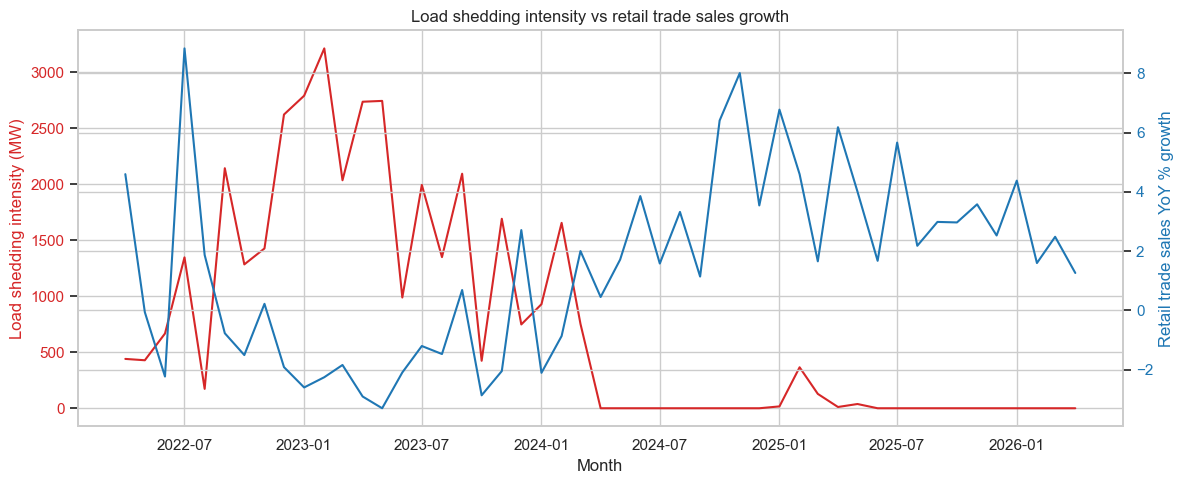

In [10]:
import os
os.makedirs(CHARTS, exist_ok=True)

df["month_dt"] = pd.to_datetime(df["month"], format="%Y-%m")

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(df["month_dt"], df["ls_intensity"], color="tab:red", label="Load shedding intensity (avg MW)")
ax1.set_xlabel("Month")
ax1.set_ylabel("Load shedding intensity (MW)", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")

ax2 = ax1.twinx()
ax2.plot(df["month_dt"], df["retail_yoy_pct"], color="tab:blue", label="Retail sales YoY % growth")
ax2.set_ylabel("Retail trade sales YoY % growth", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

plt.title("Load shedding intensity vs retail trade sales growth")
fig.tight_layout()
plt.savefig(CHARTS + "01_timeseries_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Exploratory & statistical analysis

Required (brief §3): **Pearson r, p-value, and 95% confidence interval** — correlation alone is not acceptable.

In [11]:
def pearson_with_ci(x, y, alpha=0.05):
    """Pearson r with p-value and Fisher-z confidence interval."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]
    r, p = stats.pearsonr(x, y)
    n = len(x)
    z = np.arctanh(r)
    se = 1 / np.sqrt(n - 3)
    zcrit = stats.norm.ppf(1 - alpha / 2)
    lo, hi = np.tanh(z - zcrit * se), np.tanh(z + zcrit * se)
    return {"r": r, "p": p, "n": n, "ci95": (lo, hi)}

result = pearson_with_ci(df["ls_intensity"], df["retail_yoy_pct"])
print(f"r = {result['r']:.3f}")
print(f"p = {result['p']:.4f}")
print(f"n = {result['n']}")
print(f"95% CI = ({result['ci95'][0]:.3f}, {result['ci95'][1]:.3f})")

r = -0.649
p = 0.0000
n = 49
95% CI = (-0.786, -0.450)


### Lag analysis
Does a bad load shedding month predict a retail dip 1–4 months later? Shift the economic series backwards and re-test at each lag.

In [12]:
lag_records = []

for lag in range(0, 5):
    x = df["ls_intensity"][: len(df) - lag if lag else None]
    y = df["retail_yoy_pct"].shift(-lag).dropna()
    result = pearson_with_ci(x, y)
    lag_records.append({
        "lag_months": lag,
        "n": result["n"],
        "r": round(result["r"], 3),
        "p": round(result["p"], 4),
        "ci95_low": round(result["ci95"][0], 3),
        "ci95_high": round(result["ci95"][1], 3),
        "significant_p<0.05": result["p"] < 0.05
    })

lag_df = pd.DataFrame(lag_records)
lag_df

,lag_months,n,r,p,ci95_low,ci95_high,significant_p<0.05
0,0,49,-0.649,0.0,-0.786,-0.450,True
1,1,48,-0.661,0.0,-0.796,-0.465,True
2,2,47,-0.695,0.0,-0.819,-0.510,True
3,3,46,-0.698,0.0,-0.821,-0.511,True
4,4,45,-0.665,0.0,-0.802,-0.461,True


In [13]:
sig = lag_df[lag_df["significant_p<0.05"]]
if not sig.empty:
    best = sig.loc[sig["r"].abs().idxmax()]
    print(f"Strongest significant lag: {int(best['lag_months'])} month(s) "
          f"→ r = {best['r']}, p = {best['p']}, 95% CI [{best['ci95_low']}, {best['ci95_high']}]")
else:
    print("No lag reaches p < 0.05 — the lag-0 result is the most defensible one to report.")

Strongest significant lag: 3 month(s) → r = -0.698, p = 0.0, 95% CI [-0.821, -0.511]


## 5. Modelling

### 5.1 OLS regression — quantify the impact
Target claim shape: *"each additional unit of load shedding intensity per month is associated with an X% change in retail sales, controlling for trend/seasonality."*

In [14]:
# A simple time trend (0, 1, 2, ... one per month) so we can check whether
# load shedding still matters once we account for the general year-on-year
# drift — important given the 2022-23 vs 2024+ split we just saw.
df["t"] = np.arange(len(df))

X = sm.add_constant(df[["ls_intensity", "t"]])
model = sm.OLS(df["retail_yoy_pct"], X, missing="drop").fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         retail_yoy_pct   R-squared:                       0.425
Model:                            OLS   Adj. R-squared:                  0.400
Method:                 Least Squares   F-statistic:                     16.97
Date:                Sat, 11 Jul 2026   Prob (F-statistic):           3.01e-06
Time:                        02:15:54   Log-Likelihood:                -110.70
No. Observations:                  49   AIC:                             227.4
Df Residuals:                      46   BIC:                             233.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            2.5134      1.095      2.295   

In [15]:
coef = model.params["ls_intensity"]
ci_low, ci_high = model.conf_int().loc["ls_intensity"]

calm_month = df["ls_intensity"].min()
severe_month = df["ls_intensity"].max()
mw_swing = severe_month - calm_month

print(f"Observed range: {calm_month:.0f} MW (calmest month) → {severe_month:.0f} MW (worst month)")
print(f"Point estimate: that full swing is associated with a "
      f"{coef * mw_swing:.1f} percentage-point change in retail YoY growth")
print(f"95% CI on that swing: [{ci_low * mw_swing:.1f}, {ci_high * mw_swing:.1f}] percentage points")

Observed range: 0 MW (calmest month) → 3213 MW (worst month)
Point estimate: that full swing is associated with a -6.0 percentage-point change in retail YoY growth
95% CI on that swing: [-9.1, -3.0] percentage points


### 5.2 Prophet forecast (recommended stretch — ONE model only, per brief §7)
Retail sales forecast with load shedding intensity as an extra regressor.

In [ ]:
# from prophet import Prophet
# pdf = df.rename(columns={"month": "ds", "retail_sales": "y"})
# m = Prophet()
# m.add_regressor("ls_intensity")
# m.fit(pdf)

## 6. Findings

This analysis finds a statistically significant negative relationship between Eskom's Manual Load Reduction (MLR) and South African retail trade sales growth. Across 49 months (April 2022 – April 2026), the contemporaneous Pearson correlation was r = -0.649 (p < 0.0001, 95% CI: -0.786 to -0.450) — months with heavier average load reduction were reliably associated with weaker retail trade sales growth that same month.

Testing lags of 0 to 4 months found the relationship remained statistically significant at every lag (r ranging from -0.649 at lag 0 to -0.698 at lag 3), with no meaningful decay across the window. Rather than a precise month-specific delay, this flat pattern most likely reflects the underlying structure of the data: a sustained period of severe load shedding through 2022–2023, followed by a near-complete cessation of manual load reduction from 2024 onward that coincided with stronger retail growth (see Section 3 chart).

To separate the effect of load shedding intensity from this broader shift over time, an OLS regression of retail YoY growth on load shedding intensity, controlling for a linear time trend, was estimated. Load shedding intensity remained a statistically significant predictor (coefficient = -0.0019 percentage points per MW, p < 0.001) even after accounting for time (p = 0.590, not significant on its own) — indicating load shedding intensity itself, not simply the passage of time, is doing the explanatory work.

Translated into real-world terms: the full observed range of monthly load reduction intensity — from 0 MW in the calmest months to 3,213 MW in the worst month — is associated with an estimated 6.0 percentage-point swing in retail trade sales growth (95% CI: 3.0 to 9.1 percentage points).

## 7. Limitations & honest interpretation

- **Correlation ≠ causation** — load shedding intensity co-moves with the broader business cycle
- **Confounders**: COVID-19 lockdowns (2020–21), interest-rate cycle, fuel prices, riots (July 2021)
- **Regime note**: sustained load shedding largely ended in 2024 — the informative variance sits in 2019–2023
- Sample size at monthly granularity is modest; wide CIs are expected and should be reported honestly
- **Multicollinearity**: load shedding intensity and the passage of time are closely related in this dataset (severe load shedding was concentrated early, then vanished later), reflected in the regression's high condition number (~3,950). This makes it hard to fully isolate "the effect of less load shedding" from "the effect of time passing" — the coefficient should be read as indicative of magnitude, not a precise causal isolate
- **Flat lag structure**: correlation strength did not meaningfully decay across lags 0–4 months, unlike a classic "shock that fades" pattern. This is more consistent with the 2022–23 vs 2024+ regime split than with a specific month-to-month transmission mechanism
- **Residual non-normality**: regression residuals show notable skew (Jarque-Bera p < 0.001), likely driven by a small number of extreme months (e.g. July 2022). Reported p-values should be read as solid estimates rather than exact
- A small return of load shedding in early 2025 shows no visible corresponding dip in retail growth on the chart — a case that doesn't fit the overall pattern, worth naming rather than omitting
## 8. Conclusion
This project set out to answer a specific question: does the severity of Eskom's load shedding measurably move South African retail trade sales, and by how much? The evidence here says yes. Over 49 months of real, matched data, months with heavier manual load reduction were consistently associated with weaker retail trade sales growth — a relationship that held up even after controlling for the general upward drift in retail sales over time.

The estimated scale is meaningful, not just statistically present: the difference between a calm month and Eskom's worst month is associated with roughly a 6 percentage-point swing in retail growth. At the same time, the honest reading of the data points to a story shaped more by two distinct eras — severe, sustained load shedding through 2022–2023 giving way to its near-disappearance from 2024 onward — than by a precise, predictable month-to-month delay. Correlation and a controlled regression both support a real relationship; they cannot on their own prove that load shedding causes retail sales to fall, given the other economic shocks (COVID-19 recovery, interest rates, fuel prices) unfolding across the same years.

Taken together, this analysis demonstrates that a rigorous, statistically grounded approach — real institutional data, formal hypothesis testing with confidence intervals, and a regression that controls for confounding trends — can put a defensible number on a relationship widely assumed but rarely quantified for South Africa specifically.